<a href="https://colab.research.google.com/github/lexinejazly-asuncion/Hallucination_Detection/blob/main/Hallucination_Detection_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AI Ignite Summer 2026: Hallucination Detection**

Team: Lexinejazly Asuncion, Santhosh Senthil, Siddarth Shekhar

Goal: Classify whether a claim is grounded in its source document or hallucinated, using the LLM-AggreFact dataset and Random Forrest and logistic Regression models

### **Import Libraries**




In [7]:
!pip install numpy pandas matplotlib seaborn scikit-learn sentence_transformers torch

You should consider upgrading via the '/Users/lexinejazly/AI_Ignite/.venv/bin/python3 -m pip install --upgrade pip' command.


In [8]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sentence_transformers import SentenceTransformer

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="muted")

/Users/lexinejazly/AI_Ignite/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/lexinejazly/AI_Ignite/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **Load Dataset**


In [ ]:
!pip install ipywidgets huggingface_hub

     |████████████████████████████████| 139 kB 7.2 MB/s eta 0:00:01
     |████████████████████████████████| 2.2 MB 30.2 MB/s eta 0:00:01
     |████████████████████████████████| 914 kB 77.6 MB/s eta 0:00:01
You should consider upgrading via the '/Users/lexinejazly/AI_Ignite/.venv/bin/python3 -m pip install --upgrade pip' command.


In [11]:
from huggingface_hub import login
login()

In [ ]:
dev = pd.read_parquet("hf://datasets/lytang/LLM-AggreFact/data/dev-00000-of-00001.parquet")

# Prevent contamination metadata leakage
DROP_COLS = ["contamination_identifier"]
dev.drop(columns=[c for c in DROP_COLS if c in dev.columns], inplace=True, errors="ignore")

### **Exploratory Data Analysis & Visualization**


##### Summary Statistics


In [ ]:
print(f"Total Rows (Samples) : {dev.shape[0]:,}")
print(f"Total Raw Columns    : {dev.shape[1]}")
print(f"Column Names         : {dev.columns.tolist()}\n")

# Display general dataset info
print("\nDataset Structure")
dev.info()

print("\nSummary Statistics")
display(dev.describe())

print("\nMissing Values Check")
print(dev.isnull().sum())

print("\nDuplicate (Doc, Claim) Pairs")
print(f"Duplicates count: {dev.duplicated(subset=['doc', 'claim']).sum():,}")

# Preview raw rows
print("\nFirst 5 Raw Records")
display(dev.head())

Total Rows (Samples) : 30,420
Total Raw Columns    : 4
Column Names         : ['dataset', 'doc', 'claim', 'label']


Dataset Structure
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30420 entries, 0 to 30419
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   dataset  30420 non-null  object
 1   doc      30420 non-null  object
 2   claim    30420 non-null  object
 3   label    30420 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 950.8+ KB

Summary Statistics


,label
count,30420.000000
mean,0.756673
std,0.429098
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000



Missing Values Check
dataset    0
doc        0
claim      0
label      0
dtype: int64

Duplicate (Doc, Claim) Pairs
Duplicates count: 50

First 5 Raw Records


,dataset,doc,claim,label
0,AggreFact-CNN,looking after elderly parents can be difficult...,lu xincai takes his 84-year-old mother to work...,1
1,AggreFact-CNN,tokyo ( cnn ) a bizarre and alarming discovery...,a drone carrying traces of a radioactive mater...,1
2,AggreFact-CNN,more than 25 women have been airlifted from ro...,more than 25 women have been airlifted from ro...,1
3,AggreFact-CNN,breast cancer patients may be spared chemother...,breast cancer patients may be spared chemother...,1
4,AggreFact-CNN,amazing pictures have emerged of blue fluoresc...,amazing pictures have emerged of blue fluoresc...,1


##### Hallucinated Label Distribution


In [ ]:
label_counts = dev["label"].value_counts().sort_index()
total_samples = len(dev)

print("Hallucination Label")
print(f"Hallucinated / Not Supported (0) : {label_counts.get(0, 0):,} ({label_counts.get(0, 0)/total_samples*100:.2f}%)")
print(f"Grounded / Supported (1)         : {label_counts.get(1, 0):,} ({label_counts.get(1, 0)/total_samples*100:.2f}%)")
print(f"Class Imbalance Ratio            : {label_counts.max() / label_counts.min():.2f}x\n")

Hallucination Label
Hallucinated / Not Supported (0) : 7,402 (24.33%)
Grounded / Supported (1)         : 23,018 (75.67%)
Class Imbalance Ratio            : 3.11x



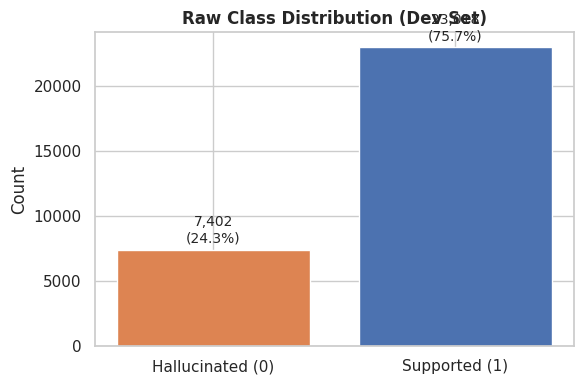

In [ ]:
# Plot Class Distribution
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Hallucinated (0)", "Supported (1)"], label_counts.values, color=["#DD8452", "#4C72B0"], edgecolor="white")
ax.set_title("Raw Class Distribution (Dev Set)", fontsize=12, fontweight="bold")
ax.set_ylabel("Count")

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:,}\n({height/total_samples*100:.1f}%)",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

##### Document and Claim Length Distribution


In [ ]:
# Calculate basic raw word counts without modifying original text
raw_doc_lens = dev["doc"].str.split().str.len()
raw_claim_lens = dev["claim"].str.split().str.len()

raw_length_df = pd.DataFrame({"doc_len": raw_doc_lens, "claim_len": raw_claim_lens, "label": dev["label"]})

print("\nRaw Text Length Distribution")
display(raw_length_df[["doc_len", "claim_len"]].describe().round(1))


Raw Text Length Distribution


,doc_len,claim_len
count,30420.0,30420.0
mean,467.2,19.7
std,721.5,9.7
min,2.0,1.0
25%,179.0,13.0
50%,323.0,18.0
75%,560.0,24.0
max,25872.0,221.0


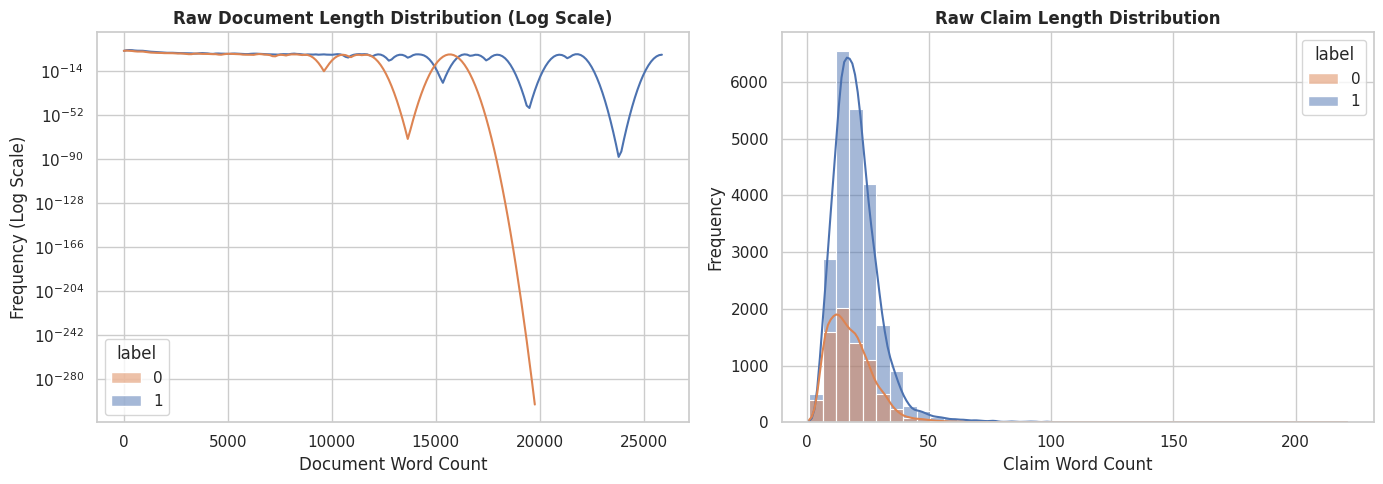

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Document Length Histograms
sns.histplot(data=raw_length_df, x="doc_len", hue="label", palette=["#DD8452", "#4C72B0"],
             bins=50, log_scale=(False, True), ax=axes[0], kde=True)
axes[0].set_title("Raw Document Length Distribution (Log Scale)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Document Word Count")
axes[0].set_ylabel("Frequency (Log Scale)")

# Claim Length Histograms
sns.histplot(data=raw_length_df, x="claim_len", hue="label", palette=["#DD8452", "#4C72B0"],
             bins=40, ax=axes[1], kde=True)
axes[1].set_title("Raw Claim Length Distribution", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Claim Word Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

##### Document Length Outliers


In [ ]:
percentiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
pct_values = raw_length_df["doc_len"].quantile(percentiles)

print("\nRaw Document Length Percentiles")
for p, v in zip(percentiles, pct_values):
    print(f"{int(p*100):2d}th Percentile : {v:,.0f} words")

# Outlier breakdown above 95th percentile
q95 = raw_length_df["doc_len"].quantile(0.95)
outlier_mask = raw_length_df["doc_len"] > q95
outlier_df = dev[outlier_mask]

print(f"\nTop 5% Longest Documents (> {q95:.0f} words): {len(outlier_df):,} rows")
print("\nOutlier Distribution across Sub-Datasets:")
print(outlier_df["dataset"].value_counts())


Raw Document Length Percentiles
10th Percentile : 107 words
25th Percentile : 179 words
50th Percentile : 323 words
75th Percentile : 560 words
90th Percentile : 889 words
95th Percentile : 1,063 words
99th Percentile : 2,629 words

Top 5% Longest Documents (> 1063 words): 1,521 rows

Outlier Distribution across Sub-Datasets:
dataset
RAGTruth          525
ClaimVerify       519
ExpertQA          290
Wice              159
AggreFact-CNN      16
AggreFact-XSum     12
Name: count, dtype: int64


##### Source Dataset Hallucination Rates


In [ ]:
source_stats = dev.groupby("dataset").agg(
    total_samples=("label", "count"),
    supported_count=("label", lambda x: (x == 1).sum()),
    hallucinated_count=("label", lambda x: (x == 0).sum()),
    hallucination_rate_pct=("label", lambda x: (1 - x.mean()) * 100),
    supported_rate_pct=("label", lambda x: x.mean() * 100)
).sort_values(by="hallucination_rate_pct", ascending=False).round(1)

print("\nSource Dataset Metrics")
display(source_stats)



Source Dataset Metrics


,total_samples,supported_count,hallucinated_count,hallucination_rate_pct,supported_rate_pct
dataset,,,,,
FactCheck-GPT,1537,266,1271,82.7,17.3
Reveal,1656,385,1271,76.8,23.2
Wice,349,115,234,67.0,33.0
AggreFact-XSum,777,394,383,49.3,50.7
Lfqa,2029,1150,879,43.3,56.7
ClaimVerify,1093,821,272,24.9,75.1
ExpertQA,3773,2941,832,22.1,77.9
TofuEval-MediaS,1800,1446,354,19.7,80.3
TofuEval-MeetB,1607,1318,289,18.0,82.0


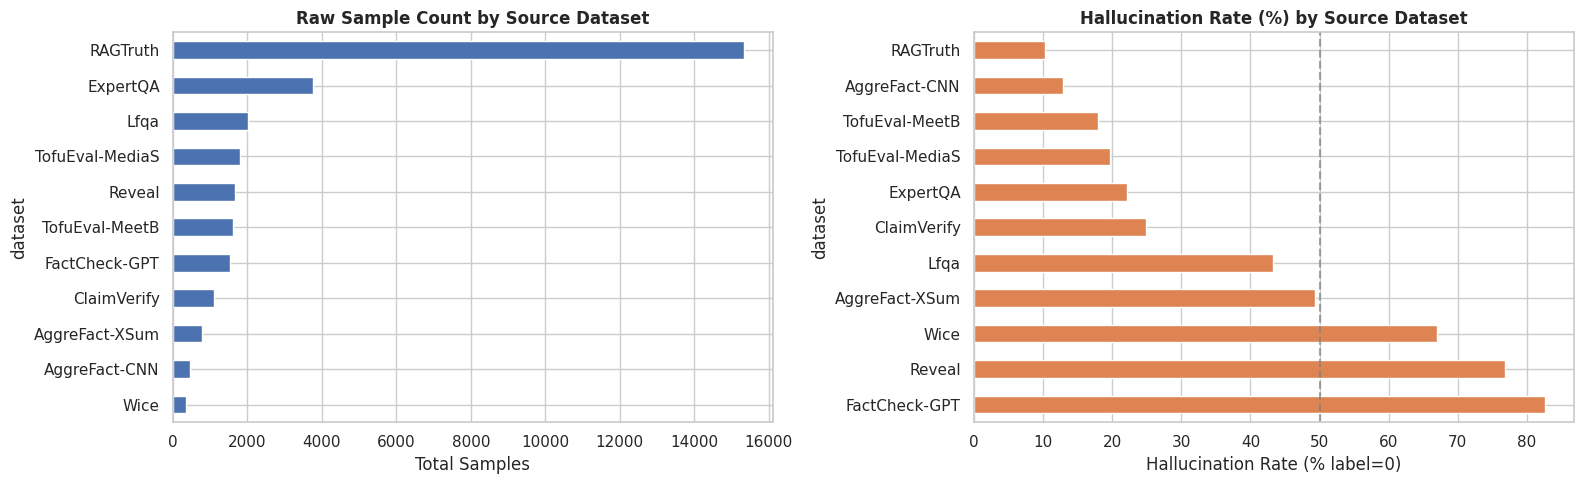

In [ ]:
# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sample count by sub-dataset
dev["dataset"].value_counts().plot(kind="barh", ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Raw Sample Count by Source Dataset", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Total Samples")
axes[0].invert_yaxis()

# Hallucination rate (%) per sub-dataset
source_stats["hallucination_rate_pct"].plot(kind="barh", ax=axes[1], color="#DD8452", edgecolor="white")
axes[1].set_title("Hallucination Rate (%) by Source Dataset", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Hallucination Rate (% label=0)")
axes[1].axvline(50, color="gray", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### **Data Split: Train and Validation**


In [ ]:
dev["strat_key"] = dev["label"].astype(str) + "_" + dev["dataset"].astype(str)

train_df, val_df = train_test_split(
    dev,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=dev["strat_key"],
)

train_df = train_df.drop(columns=["strat_key"]).reset_index(drop=True)
val_df   = val_df.drop(columns=["strat_key"]).reset_index(drop=True)

print(f"Train set : {len(train_df):,} samples")
print(f"Val set   : {len(val_df):,} samples")

Train set : 24,336 samples
Val set   : 6,084 samples


### **Data Preprocessing: Text Normalization & Feature Engineering**


In [ ]:
STOPWORDS = set("a an the and or but if that this these those of to as be been being it its so such".split())

def normalize(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s.,!?'-]", " ", text)
    return text.strip()

def overlap_features(row):
    doc_toks   = row["doc_clean"].split()
    claim_toks = row["claim_clean"].split()
    doc_set, claim_set = set(doc_toks), set(claim_toks)

    claim_content = claim_set - STOPWORDS
    doc_content   = doc_set - STOPWORDS

    coverage = len(claim_content & doc_content) / len(claim_content) if claim_content else 0.0

    union = claim_set | doc_set
    jaccard = len(claim_set & doc_set) / len(union) if union else 0.0

    def bigrams(toks):
        return set(zip(toks, toks[1:]))

    cb, db = bigrams(claim_toks), bigrams(doc_toks)
    bigram_cov = len(cb & db) / len(cb) if cb else 0.0

    claim_nums = set(re.findall(r"\d+\.?\d*", row["claim_clean"]))
    doc_nums   = set(re.findall(r"\d+\.?\d*", row["doc_clean"]))

    if claim_nums:
        num_grounded  = len(claim_nums & doc_nums) / len(claim_nums)
        has_novel_num = int(len(claim_nums - doc_nums) > 0)
    else:
        num_grounded, has_novel_num = 1.0, 0

    return pd.Series({
        "coverage":        coverage,
        "jaccard":         jaccard,
        "bigram_cov":      bigram_cov,
        "num_grounded":    num_grounded,
        "has_novel_num":   has_novel_num,
        "claim_len":       len(claim_toks),
        "doc_len":         len(doc_toks),
        "n_content_words": len(claim_content),
    })

def preprocess_dataframe(df):
    df = df.copy()
    df["doc_clean"]   = df["doc"].apply(normalize)
    df["claim_clean"] = df["claim"].apply(normalize)
    feats = df.apply(overlap_features, axis=1)
    return pd.concat([df, feats], axis=1)

In [ ]:
# Preprocess Train Set
train = preprocess_dataframe(train_df)

### **Similarity Features**


In [ ]:
# Lexical Similarity (Fit TF-IDF on train_df)
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=3, sublinear_tf=True)
tfidf.fit(pd.concat([train["doc_clean"], train["claim_clean"]]))

def compute_lexical_sim(df):
    d = tfidf.transform(df["doc_clean"])
    c = tfidf.transform(df["claim_clean"])
    return np.asarray(d.multiply(c).sum(axis=1)).flatten()

In [ ]:
# Semantic Similarity (Sentence-Transformers)
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

def compute_semantic_sim(df):
    d = embedding_model.encode(df["doc_clean"].tolist(), convert_to_numpy=True, show_progress_bar=False)
    c = embedding_model.encode(df["claim_clean"].tolist(), convert_to_numpy=True, show_progress_bar=False)
    d = d / (np.linalg.norm(d, axis=1, keepdims=True) + 1e-9)
    c = c / (np.linalg.norm(c, axis=1, keepdims=True) + 1e-9)
    return np.sum(d * c, axis=1)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Apply similarity score to training set
train["lexical_sim"]  = compute_lexical_sim(train)
train["semantic_sim"] = compute_semantic_sim(train)

In [ ]:
NUMERIC_FEATS = [
    "coverage",
    "bigram_cov",
    "num_grounded",
    "has_novel_num",
    "claim_len",
    "n_content_words",
    "lexical_sim",
    "semantic_sim"
]

X_train = train[NUMERIC_FEATS]
y_train = train["label"]

### **Model Training: Grid Search CV**


In [ ]:
# Splitting the data
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Models
# Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000))
])

lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0],
    'classifier__solver': ['lbfgs', 'liblinear']
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=kf,
    scoring='f1_weighted',
    n_jobs=-1,
    return_train_score=True
)

# Random Forrest
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])

rf_param_grid = {
    'classifier__n_estimators': [25, 50, 100, 150],
    'classifier__max_depth': [5, 10, 15],
    'classifier__min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=kf,
    scoring='f1_weighted',
    n_jobs=-1,
    return_train_score=True
)

In [ ]:
# GridSearch for Logistic Regression
lr_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('classifier',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1.0, 10.0],
                         'classifier__solver': ['lbfgs', 'liblinear']},
             return_train_score=True, scoring='f1_weighted')

In [ ]:
# Running GridSearch for Random Forest
rf_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('classifier',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10, 15],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__n_estimators': [25, 50, 100, 150]},
             return_train_score=True, scoring='f1_weighted')

### **Grid Search CV Summary**


In [ ]:
# Extract fold-by-fold results from GridSearchCV
cv_results_data = []

grid_models = {
    "Logistic Regression": lr_grid,
    "Random Forest": rf_grid
}

for model_name, grid_obj in grid_models.items():
    best_index = grid_obj.best_index_

    for fold in range(kf.get_n_splits()):

        test_key = f"split{fold}_test_score"
        train_key = f"split{fold}_train_score"

        # Retrieve fold scores for the best parameter combination
        test_score = grid_obj.cv_results_[f"split{fold}_test_score"][best_index]
        if train_key in grid_obj.cv_results_:
            train_score = grid_obj.cv_results_[train_key][best_index]
        else:
            train_score = np.nan

        cv_results_data.append({
            "Model": model_name,
            "Fold": fold + 1,
            "Test Score (F1)": test_score,
            "Train Score (F1)": train_score,
            "Test Error": 1 - test_score,
            "Train Error": 1 - train_score if not np.isnan(train_score) else np.nan
        })

cv_df = pd.DataFrame(cv_results_data)

In [ ]:
# Print Summary Results Table
summary_table = cv_df.groupby("Model").agg({
    "Test Score (F1)": ["mean", "std"],
    "Test Error": ["mean", "std"]
}).round(4)
display(summary_table)


Test Score (F1)         Test Error        
                               mean     std       mean     std
Model                                                         
Logistic Regression          0.6763  0.0073     0.3237  0.0073
Random Forest                0.7506  0.0018     0.2494  0.0018

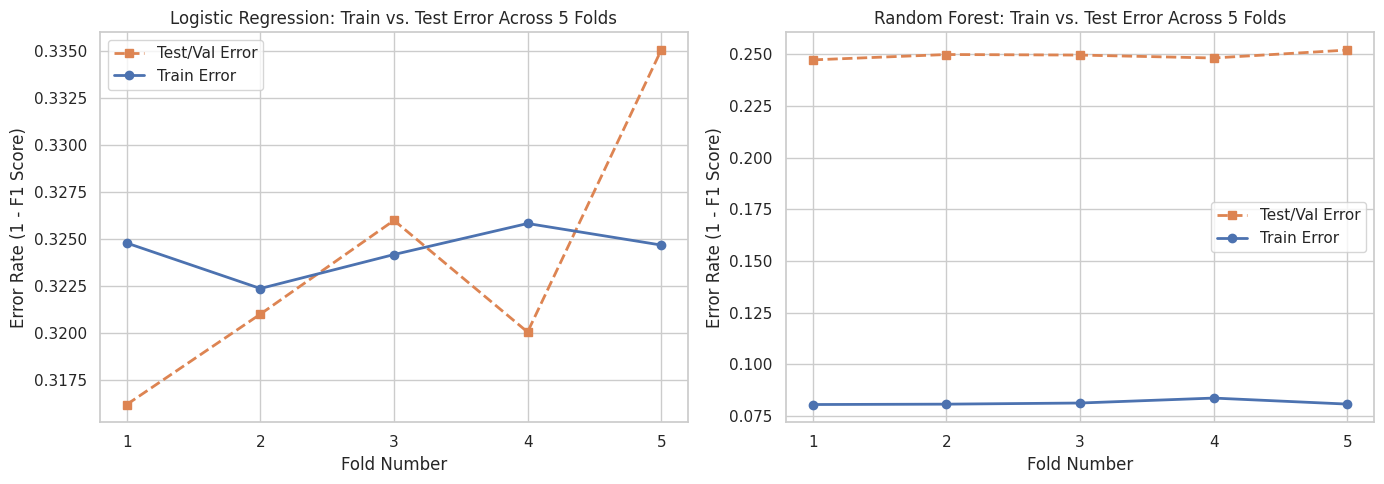

In [ ]:
# Plot Train vs. Test Error Across Folds
plt.figure(figsize=(14, 5))

models_to_plot = cv_df["Model"].unique()
folds = np.arange(1, kf.get_n_splits() + 1)

for idx, m_name in enumerate(models_to_plot, 1):
    plt.subplot(1, len(models_to_plot), idx)
    sub_df = cv_df[cv_df["Model"] == m_name]

    # Plot Test Error
    plt.plot(sub_df["Fold"], sub_df["Test Error"], marker='s', linewidth=2, linestyle='--', label="Test/Val Error", color="#DD8452")

    # Plot Train Error
    plt.plot(sub_df["Fold"], sub_df["Train Error"], marker='o', linewidth=2, label="Train Error", color="#4C72B0")

    plt.xticks(folds)
    plt.xlabel("Fold Number")
    plt.ylabel("Error Rate (1 - F1 Score)")
    plt.title(f"{m_name}: Train vs. Test Error Across 5 Folds")
    plt.legend()

plt.tight_layout()
plt.show()

### **Fine Tuning Models**


In [ ]:
# Best Parameters
print("Best Logistic Regression Params :", lr_grid.best_params_)
print("Best Random Forest Params       :", rf_grid.best_params_)

Best Logistic Regression Params : {'classifier__C': 0.01, 'classifier__solver': 'lbfgs'}
Best Random Forest Params       : {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}


In [ ]:
best_lr_model = lr_grid.best_estimator_
best_rf_model = rf_grid.best_estimator_

### **Evaluation on Validation Set**


In [ ]:
val = preprocess_dataframe(val_df)

In [ ]:
# Apply similarity score to validation set
val["lexical_sim"]  = compute_lexical_sim(val)
val["semantic_sim"] = compute_semantic_sim(val)

In [ ]:
X_val = val[NUMERIC_FEATS]
y_val = val["label"]

In [ ]:
def evaluate_pipeline(pipeline_model, X, y, split_name, model_name, threshold=0.5):
    y_true = y.values if hasattr(y, 'values') else y
    probs = pipeline_model.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)

    acc = accuracy_score(y_true, preds)
    prec = precision_score(y_true, preds, pos_label=0, zero_division=0)
    rec = recall_score(y_true, preds, pos_label=0, zero_division=0)
    f1_minority = f1_score(y_true, preds, pos_label=0, zero_division=0)
    auc = roc_auc_score(y_true, probs)

    print(f"[{split_name}] {model_name} (Threshold: {threshold:.2f}):")
    print(f"  Accuracy                : {acc:.4f}")
    print(f"  Hallucinated Precision  : {prec:.4f}")
    print(f"  Hallucinated Recall     : {rec:.4f}")
    print(f"  Hallucinated F1 Score   : {f1_minority:.4f}")
    print(f"  AUC-ROC                 : {auc:.4f}\n")

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_minority": f1_minority,
        "auc": auc
    }

In [ ]:
# Evaluate Tuned Logistic Regression
lr_val_metrics = evaluate_pipeline(
    pipeline_model=best_lr_model,
    X=X_val,
    y=y_val,
    split_name="Validation",
    model_name="Tuned Logistic Regression"
)

# Evaluate Tuned Random Forest
rf_val_metrics = evaluate_pipeline(
    pipeline_model=best_rf_model,
    X=X_val,
    y=y_val,
    split_name="Validation",
    model_name="Tuned Random Forest"
)

[Validation] Tuned Logistic Regression (Threshold: 0.50):
  Accuracy                : 0.6481
  Hallucinated Precision  : 0.3821
  Hallucinated Recall     : 0.7225
  Hallucinated F1 Score   : 0.4999
  AUC-ROC                 : 0.7411

[Validation] Tuned Random Forest (Threshold: 0.50):
  Accuracy                : 0.7525
  Hallucinated Precision  : 0.4917
  Hallucinated Recall     : 0.4997
  Hallucinated F1 Score   : 0.4956
  AUC-ROC                 : 0.7647



### Threshold Optimization
Evaluate a range of decision thresholds on the validation set and select the threshold that minimizes hallucinated false negatives (actual hallucinated claims predicted as supported).

In [ ]:
def threshold_metrics_by_fn(model, X, y, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95)
    probs = model.predict_proba(X)[:, 1]
    records = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
        false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0.0
        records.append({
            "threshold": round(t, 2),
            "false_negatives": fn,
            "false_negative_rate": false_negative_rate,
            "hallucinated_recall": recall_score(y, preds, pos_label=0, zero_division=0),
            "hallucinated_precision": precision_score(y, preds, pos_label=0, zero_division=0),
            "false_positives": fp
        })
    return pd.DataFrame(records)

lr_threshold_df = threshold_metrics_by_fn(best_lr_model, X_val, y_val)
rf_threshold_df = threshold_metrics_by_fn(best_rf_model, X_val, y_val)

lr_best = lr_threshold_df.sort_values(["false_negative_rate", "false_negatives", "threshold"], ascending=[True, True, False]).iloc[0]  # keep higher threshold when tied
rf_best = rf_threshold_df.sort_values(["false_negative_rate", "false_negatives", "threshold"], ascending=[True, True, False]).iloc[0]

print("Logistic Regression best threshold by lowest hallucinated false-negative rate:")
print(lr_best.to_dict())
print("Random Forest best threshold by lowest hallucinated false-negative rate:")
print(rf_best.to_dict())

display(lr_threshold_df.head(10))
display(rf_threshold_df.head(10))

plt.figure(figsize=(10, 5))
plt.plot(lr_threshold_df["threshold"], lr_threshold_df["false_negative_rate"], label="Logistic Regression")
plt.plot(rf_threshold_df["threshold"], rf_threshold_df["false_negative_rate"], label="Random Forest")
plt.xlabel("Threshold")
plt.ylabel("Hallucinated False Negative Rate")
plt.title("Threshold Optimization: False Negative Rate vs. Threshold")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
metrics_df = pd.DataFrame([
    {"Model": "Logistic Regression", **lr_val_metrics},
    {"Model": "Random Forest", **rf_val_metrics}
])

metrics_melted = metrics_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

metric_labels = {
    "accuracy": "Accuracy",
    "precision": "Precision (Class 0)",
    "recall": "Recall (Class 0)",
    "f1_minority": "F1-Score (Class 0)",
    "auc": "AUC-ROC"
}
metrics_melted["Metric"] = metrics_melted["Metric"].map(metric_labels)

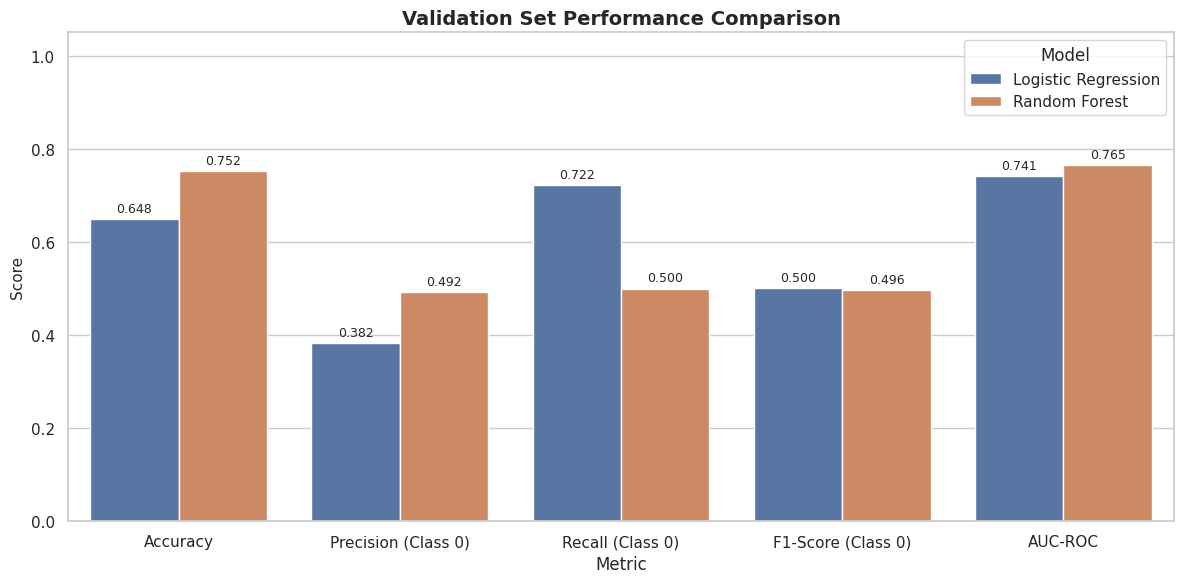

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=metrics_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette=["#4C72B0", "#DD8452"],
    edgecolor="white"
)

plt.title("Validation Set Performance Comparison", fontsize=14, fontweight="bold")
plt.ylabel("Score", fontsize=11)
plt.ylim(0, 1.05)
plt.legend(title="Model", frameon=True)

# Annotate bar values
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.3f}",
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=9, xytext=(0, 3),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()

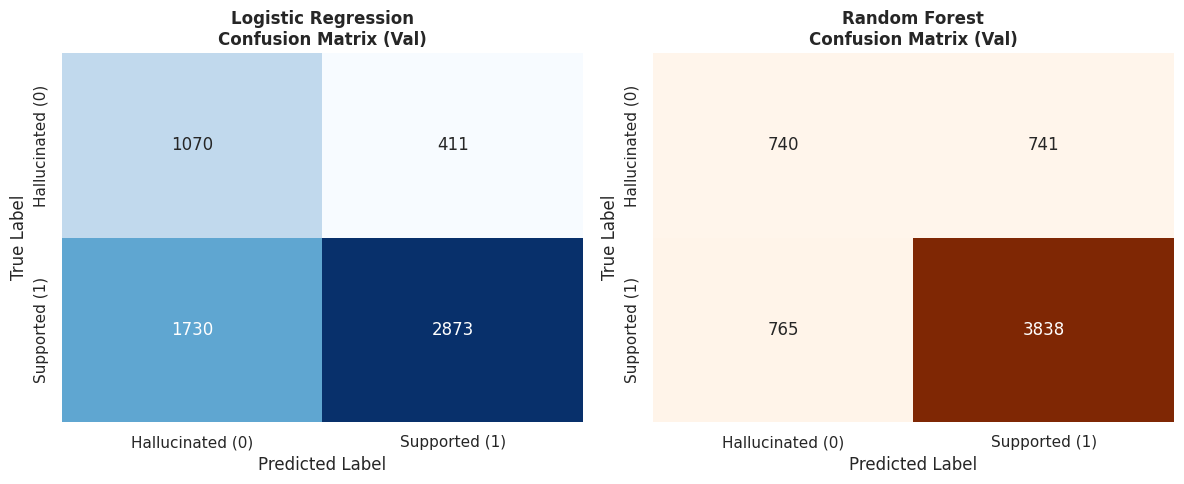

In [ ]:
y_val_true = val["label"].values

# Get predicted classes and probabilities
lr_val_probs = best_lr_model.predict_proba(X_val)[:, 1]
rf_val_probs = best_rf_model.predict_proba(X_val)[:, 1]

lr_val_preds = (lr_val_probs >= 0.5).astype(int)
rf_val_preds = (rf_val_probs >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_val_true, lr_val_preds)
sns.heatmap(
    cm_lr, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
    xticklabels=["Hallucinated (0)", "Supported (1)"],
    yticklabels=["Hallucinated (0)", "Supported (1)"]
)
axes[0].set_title("Logistic Regression\nConfusion Matrix (Val)", fontweight="bold")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Plot 2: Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_val_true, rf_val_preds)
sns.heatmap(
    cm_rf, annot=True, fmt="d", cmap="Oranges", cbar=False, ax=axes[1],
    xticklabels=["Hallucinated (0)", "Supported (1)"],
    yticklabels=["Hallucinated (0)", "Supported (1)"]
)
axes[1].set_title("Random Forest\nConfusion Matrix (Val)", fontweight="bold")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

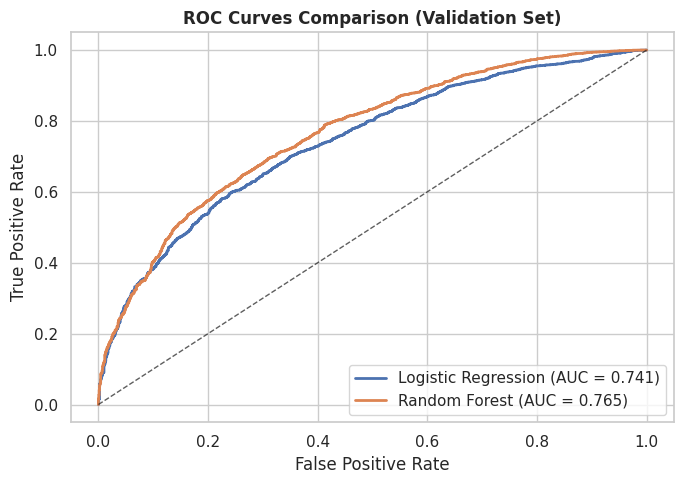

In [ ]:
# Calculate ROC curves and AUC scores
fpr_lr, tpr_lr, _ = roc_curve(y_val_true, lr_val_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_val_true, rf_val_probs)

auc_lr = roc_auc_score(y_val_true, lr_val_probs)
auc_rf = roc_auc_score(y_val_true, rf_val_probs)

plt.figure(figsize=(7, 5))

# Plot curves
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})", color="#4C72B0", lw=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})", color="#DD8452", lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.7)

plt.title("ROC Curves Comparison (Validation Set)", fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
train_val_error_data = []

models_dict = {
    "Logistic Regression": best_lr_model,
    "Random Forest": best_rf_model
}

for name, model in models_dict.items():
    # Predictions
    train_preds = model.predict(X_train)
    val_preds   = model.predict(X_val)

    # F1 Scores (Weighted)
    train_f1 = f1_score(y_train, train_preds, average='weighted')
    val_f1   = f1_score(y_val, val_preds, average='weighted')

    # Error Rates (1 - F1)
    train_err = 1.0 - train_f1
    val_err   = 1.0 - val_f1

    train_val_error_data.append({
        "Model": name,
        "Train F1": train_f1,
        "Val F1": val_f1,
        "Train Error": train_err,
        "Validation Error": val_err,
        "Generalization Gap (Val - Train Error)": val_err - train_err
    })

train_val_df = pd.DataFrame(train_val_error_data)

display(train_val_df.round(4))

,Model,Train F1,Val F1,Train Error,Validation Error,Generalization Gap (Val - Train Error)
0,Logistic Regression,0.6758,0.6729,0.3242,0.3271,0.0029
1,Random Forest,0.9050,0.7531,0.0950,0.2469,0.1518


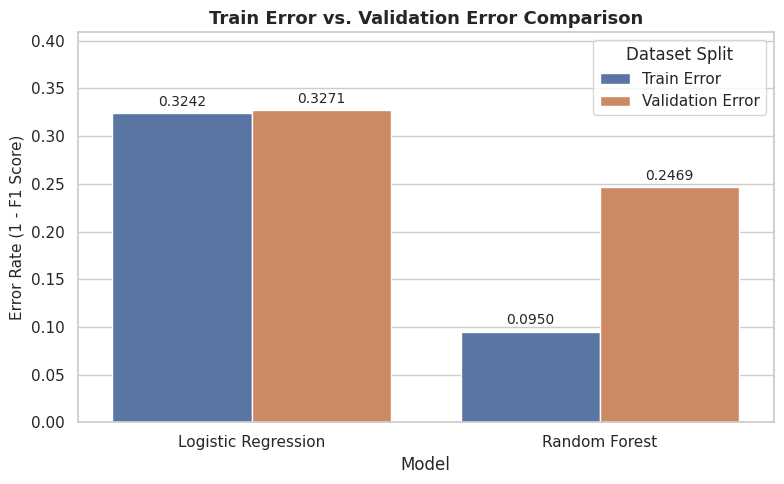

In [ ]:
plot_df = train_val_df.melt(
    id_vars="Model",
    value_vars=["Train Error", "Validation Error"],
    var_name="Split",
    value_name="Error Rate"
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=plot_df,
    x="Model",
    y="Error Rate",
    hue="Split",
    palette=["#4C72B0", "#DD8452"],
    edgecolor="white"
)

plt.title("Train Error vs. Validation Error Comparison", fontsize=13, fontweight="bold")
plt.ylabel("Error Rate (1 - F1 Score)", fontsize=11)
plt.ylim(0, max(plot_df["Error Rate"]) * 1.25)
plt.legend(title="Dataset Split", frameon=True)

# Add numeric annotations on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.4f}",
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=10, xytext=(0, 3),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()

### **Testing**

In [ ]:
test_df = pd.read_parquet("hf://datasets/lytang/LLM-AggreFact/data/test-00000-of-00001.parquet")

test_processed = preprocess_dataframe(test_df)

test_processed["lexical_sim"]  = compute_lexical_sim(test_processed)
test_processed["semantic_sim"] = compute_semantic_sim(test_processed)

X_test = test_processed[NUMERIC_FEATS]
y_test = test_processed["label"].values

In [ ]:
def evaluate_test_performance(model, X, y, model_name):
    probs = model.predict_proba(X)[:, 1]
    preds = (probs >= 0.5).astype(int)

    acc  = accuracy_score(y, preds)
    prec = precision_score(y, preds, pos_label=0, zero_division=0)
    rec  = recall_score(y, preds, pos_label=0, zero_division=0)
    f1_min = f1_score(y, preds, pos_label=0, zero_division=0)
    f1_w  = f1_score(y, preds, average="weighted")
    auc  = roc_auc_score(y, probs)

    print(f"{model_name} (Test Set)")
    print(f"  Accuracy                      : {acc:.4f}")
    print(f"  Hallucinated Precision (0)    : {prec:.4f}")
    print(f"  Hallucinated Recall (0)       : {rec:.4f}")
    print(f"  Hallucinated F1 Score (0)     : {f1_min:.4f}")
    print(f"  Weighted F1 Score             : {f1_w:.4f}")
    print(f"  AUC-ROC                       : {auc:.4f}\n")

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision (Hallucinated)": prec,
        "Recall (Hallucinated)": rec,
        "F1 (Hallucinated)": f1_min,
        "Weighted F1": f1_w,
        "AUC-ROC": auc,
        "probs": probs,
        "preds": preds
    }

In [ ]:
lr_test_res = evaluate_test_performance(best_lr_model, X_test, y_test, "Tuned Logistic Regression")
rf_test_res = evaluate_test_performance(best_rf_model, X_test, y_test, "Tuned Random Forest")

Tuned Logistic Regression (Test Set)
  Accuracy                      : 0.6480
  Hallucinated Precision (0)    : 0.3546
  Hallucinated Recall (0)       : 0.7203
  Hallucinated F1 Score (0)     : 0.4752
  Weighted F1 Score             : 0.6777
  AUC-ROC                       : 0.7372

Tuned Random Forest (Test Set)
  Accuracy                      : 0.7569
  Hallucinated Precision (0)    : 0.4539
  Hallucinated Recall (0)       : 0.4852
  Hallucinated F1 Score (0)     : 0.4690
  Weighted F1 Score             : 0.7598
  AUC-ROC                       : 0.7577



### **Final Evaluation**


In [ ]:
test_summary_df = pd.DataFrame([
    {k: v for k, v in lr_test_res.items() if k not in ["probs", "preds"]},
    {k: v for k, v in rf_test_res.items() if k not in ["probs", "preds"]}
])

display(test_summary_df.round(4))

,Model,Accuracy,Precision (Hallucinated),Recall (Hallucinated),F1 (Hallucinated),Weighted F1,AUC-ROC
0,Tuned Logistic Regression,0.6480,0.3546,0.7203,0.4752,0.6777,0.7372
1,Tuned Random Forest,0.7569,0.4539,0.4852,0.4690,0.7598,0.7577


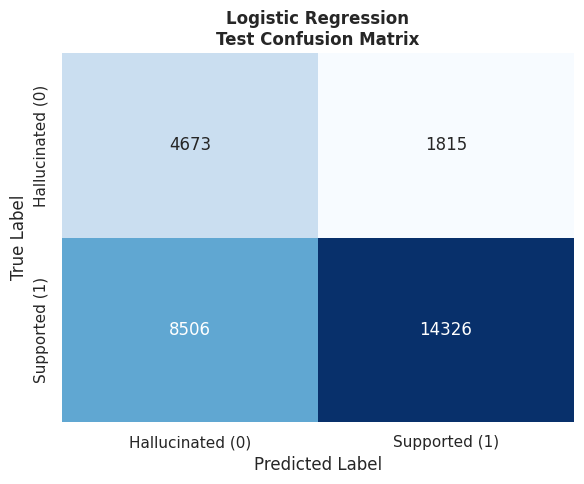

In [ ]:
plt.figure(figsize=(6, 5))

cm_lr = confusion_matrix(y_test, lr_test_res["preds"])
sns.heatmap(
    cm_lr, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Hallucinated (0)", "Supported (1)"],
    yticklabels=["Hallucinated (0)", "Supported (1)"]
)
plt.title("Logistic Regression\nTest Confusion Matrix", fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

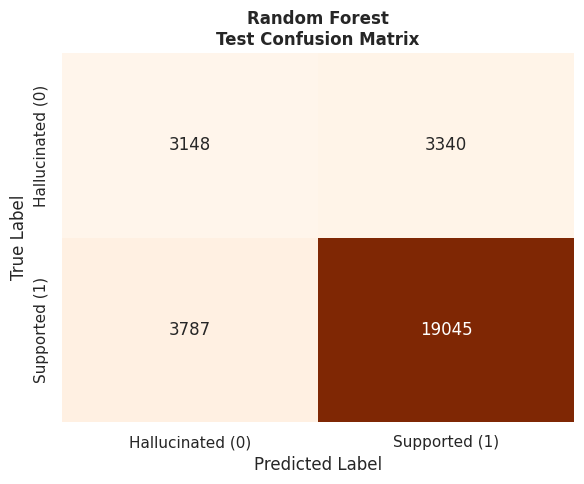

In [ ]:
plt.figure(figsize=(6, 5))

cm_rf = confusion_matrix(y_test, rf_test_res["preds"])
sns.heatmap(
    cm_rf, annot=True, fmt="d", cmap="Oranges", cbar=False,
    xticklabels=["Hallucinated (0)", "Supported (1)"],
    yticklabels=["Hallucinated (0)", "Supported (1)"]
)
plt.title("Random Forest\nTest Confusion Matrix", fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

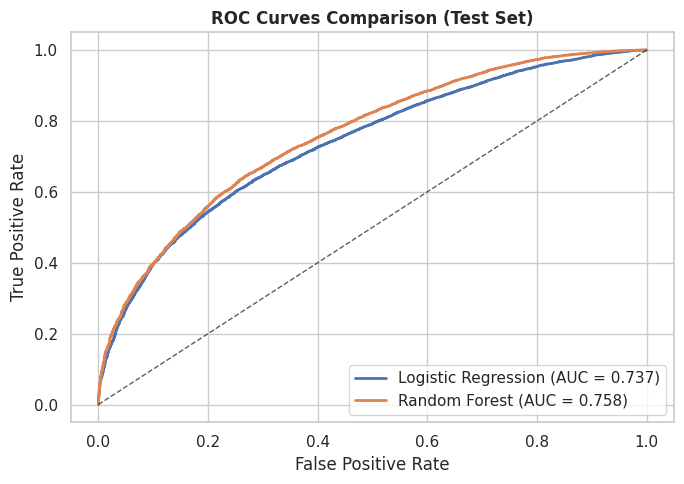

In [ ]:
plt.figure(figsize=(7, 5))

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_test_res["probs"])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_test_res["probs"])

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {lr_test_res['AUC-ROC']:.3f})", color="#4C72B0", lw=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_test_res['AUC-ROC']:.3f})", color="#DD8452", lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.7)

plt.title("ROC Curves Comparison (Test Set)", fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### **Model Prediction**


In [ ]:
# Takes a trained model and input features, returning the predicted class
# and the probability of it being Supported (1).

def classify_and_score(model, X_input, threshold=0.50):
    # Get the probability for the positive class (Supported = 1)
    probabilities = model.predict_proba(X_input)[:, 1]

    # Determine the class label based on your threshold
    predictions = (probabilities >= threshold).astype(int)

    # Combine them into a list of dictionaries for easy reading
    results = []
    for pred, prob in zip(predictions, probabilities):
        results.append({
            "predicted_label": pred,
            "probability": prob
        })

    return results

In [ ]:
import pandas as pd

# Takes a raw document and claim, runs them through the preprocessing pipeline,
# and returns the model's prediction and confidence score.

def predict_hallucination(model, document_text, claim_text, threshold=0.50):
    # Put the raw text into a DataFrame
    input_df = pd.DataFrame([{"doc": document_text, "claim": claim_text}])

    # Run your existing text normalization and overlap features
    processed_df = preprocess_dataframe(input_df)

    # Compute and add the similarity features
    processed_df["lexical_sim"] = compute_lexical_sim(processed_df)
    processed_df["semantic_sim"] = compute_semantic_sim(processed_df)

    # Isolate the exact columns the model expects
    X_input = processed_df[NUMERIC_FEATS]

    # Get the prediction and probability
    probability = model.predict_proba(X_input)[0, 1]
    predicted_label = 1 if probability >= threshold else 0

    return {
        "document": document_text,
        "claim": claim_text,
        "predicted_label": predicted_label,
        "probability": probability,
        "output": "Supported" if predicted_label == 1 else "Hallucinated"
    }